# WR Feature Selection & Learning Curves

**Goals:**
1. Use XGBoost & LightGBM feature importance to select the top 40 features
2. Compare learning curves (loss per boosting round) with **all 184 features** vs **top 40 features**
3. Compare final test metrics to quantify the impact of feature reduction

Data pipeline is identical to `WR_Career_RNN_Optuna.ipynb`.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import os, json, time

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['figure.figsize'] = (14, 5)

SEED = 42
np.random.seed(SEED)

print('Ready')

Ready


---
## 1. Data Loading & Feature Engineering

Identical pipeline to `WR_Career_RNN_Optuna.ipynb` — career-based lag1, roll5, momentum, interaction features.

In [2]:
df = pd.read_csv('../data/fully combined/wr_all_weeks.csv')
df['week'] = df['game_id'].str.split('_').str[1].astype(int)
df = df.sort_values(['receiver_player_id', 'season', 'week']).reset_index(drop=True)
print(f'Shape: {df.shape}')
print(f'Seasons: {sorted(df["season"].unique())}')
print(f'Unique players: {df["receiver_player_id"].nunique()}')

Shape: (46115, 100)
Seasons: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Unique players: 1719


In [3]:
work_df = df.copy()

# --- Rename WP columns ---
wp_rename_map = {
    'yards_wp_<25': 'yards_wp_less_than_25',
    'yards_wp_>75': 'yards_wp_greater_than_75',
    'receptions_wp_<25': 'receptions_wp_less_than_25',
    'receptions_wp_>75': 'receptions_wp_greater_than_75',
    'targets_wp_<25': 'targets_wp_less_than_25',
    'targets_wp_>75': 'targets_wp_greater_than_75',
}
work_df = work_df.rename(columns={k: v for k, v in wp_rename_map.items() if k in work_df.columns})

# --- Infer player team and detect changes ---
work_df['player_team_inferred'] = np.where(
    (work_df['home_team'] == work_df['defteam']) & (work_df['away_team'] != work_df['defteam']),
    work_df['away_team'],
    np.where(
        (work_df['away_team'] == work_df['defteam']) & (work_df['home_team'] != work_df['defteam']),
        work_df['home_team'], np.nan
    )
)

prev_team = work_df.groupby('receiver_player_id')['player_team_inferred'].shift(1)
work_df['team_changed'] = (
    work_df['player_team_inferred'].notna() & prev_team.notna()
    & (work_df['player_team_inferred'] != prev_team)
).astype(int)

prev_season = work_df.groupby('receiver_player_id')['season'].shift(1)
work_df['is_new_season'] = (
    prev_season.notna() & (work_df['season'] != prev_season)
).astype(int)

# --- Weeks since last game ---
work_df['season_week_abs'] = (work_df['season'] - 2015) * 22 + work_df['week']
work_df['weeks_since_last_game'] = (
    work_df.groupby('receiver_player_id')['season_week_abs']
    .diff().fillna(1).clip(lower=1).astype(float)
)
work_df.drop(columns=['season_week_abs'], inplace=True)

print(f'team_changed: {work_df["team_changed"].sum()} rows')
print(f'is_new_season: {work_df["is_new_season"].sum()} rows')

team_changed: 1133 rows
is_new_season: 3755 rows


In [4]:
# --- Previous-season career features ---
season_career = (
    work_df.groupby(['receiver_player_id', 'season'], as_index=False)
    .agg(
        avg_yards=('receiving_yards', 'mean'),
        avg_target_share=('target_share', 'mean'),
        avg_epa=('epa', 'mean'),
        avg_air_yard_share=('air_yard_share', 'mean'),
        avg_catch_rate=('catch_rate', 'mean'),
        games_played=('game_id', 'count')
    )
    .sort_values(['receiver_player_id', 'season'])
)

for c in ['avg_yards', 'avg_target_share', 'avg_epa',
          'avg_air_yard_share', 'avg_catch_rate', 'games_played']:
    season_career[f'{c}_last_season'] = (
        season_career.groupby('receiver_player_id')[c].shift(1)
    )

career_cols = [
    'avg_yards_last_season', 'avg_target_share_last_season',
    'avg_epa_last_season', 'avg_air_yard_share_last_season',
    'avg_catch_rate_last_season', 'games_played_last_season',
]
season_career = season_career[['receiver_player_id', 'season'] + career_cols]
work_df = work_df.merge(season_career, on=['receiver_player_id', 'season'], how='left')
work_df[career_cols] = work_df[career_cols].fillna(0)
print(f'Career features added: {len(career_cols)}')

Career features added: 6


In [5]:
# --- Lag1 and Roll5 features (CAREER-BASED) ---
rolling_source_cols = [
    'targets', 'receptions', 'air_yards', 'yac', 'tds', 'epa', 'wpa', 'catch_rate',
    'avg_depth', 'adot', 'yac_per_reception', 'td_rate', 'explosive_plays', 'first_downs',
    'yards_per_target', 'team_pass_attempts', 'team_air_yards', 'team_epa', 'air_yard_share',
    'target_share', 'qb_completions', 'qb_attempts', 'qb_air_yards', 'qb_cpoe', 'qb_comp_pct',
    'avg_score_diff', 'trailing_pct', 'leading_pct', 'avg_quarter', 'success_rate',
    'big_play_rate', 'avg_start_yardline', 'red_zone_targets', 'end_zone_targets',
    'third_down_targets', 'fourth_down_targets', 'high_leverage_targets',
    'second_and_long_targets', 'third_and_medium_targets', 'wp_var', 'target_share_std',
    'reception_std', 'def_targets_dev', 'def_receptions_dev', 'def_yards_dev', 'def_tds_dev',
    'def_epa_dev', 'yards_Q1', 'yards_Q2', 'yards_Q3', 'yards_Q4',
    'receptions_Q1', 'receptions_Q2', 'receptions_Q3', 'receptions_Q4',
    'targets_Q1', 'targets_Q2', 'targets_Q3', 'targets_Q4',
    'lost_yards_due_to_penalty',
    'yards_wp_less_than_25', 'yards_wp_25_45', 'yards_wp_45_55',
    'yards_wp_55_75', 'yards_wp_greater_than_75',
    'receptions_wp_less_than_25', 'receptions_wp_25_45', 'receptions_wp_45_55',
    'receptions_wp_55_75', 'receptions_wp_greater_than_75',
    'targets_wp_less_than_25', 'targets_wp_25_45', 'targets_wp_45_55',
    'targets_wp_55_75', 'targets_wp_greater_than_75',
    'weeks_since_last_game',
]

available_roll_cols = [c for c in rolling_source_cols if c in work_df.columns]
print(f'Rolling source columns found: {len(available_roll_cols)}')

grp = work_df.groupby('receiver_player_id', sort=False)
derived_cols = []

for col in available_roll_cols:
    work_df[f'{col}_lag1'] = grp[col].transform(lambda s: s.shift(1))
    work_df[f'{col}_roll5'] = grp[col].transform(
        lambda s: s.shift(1).rolling(window=5, min_periods=1).mean()
    )
    derived_cols.extend([f'{col}_lag1', f'{col}_roll5'])

work_df = work_df.drop(columns=available_roll_cols)
print(f'Derived lag1+roll5 features: {len(derived_cols)}')

Rolling source columns found: 76
Derived lag1+roll5 features: 152


In [6]:
# --- Momentum features ---
momentum_sources = [
    'targets', 'receptions', 'air_yards', 'epa', 'catch_rate',
    'target_share', 'yards_per_target', 'air_yard_share',
]
momentum_cols = []
for col in momentum_sources:
    lag1_col = f'{col}_lag1'
    roll5_col = f'{col}_roll5'
    if lag1_col in work_df.columns and roll5_col in work_df.columns:
        mcol = f'{col}_momentum'
        work_df[mcol] = work_df[lag1_col] - work_df[roll5_col]
        momentum_cols.append(mcol)

# --- Interaction features ---
interaction_cols = []

if 'target_share_lag1' in work_df.columns:
    work_df['target_volume_interaction'] = (
        work_df['target_share_lag1'] * work_df['pregame_total']
    )
    interaction_cols.append('target_volume_interaction')

if 'air_yard_share_lag1' in work_df.columns and 'team_pass_attempts_lag1' in work_df.columns:
    work_df['air_yards_expected'] = (
        work_df['air_yard_share_lag1'] * work_df['team_pass_attempts_lag1']
    )
    interaction_cols.append('air_yards_expected')

if 'catch_rate_lag1' in work_df.columns and 'targets_lag1' in work_df.columns:
    work_df['expected_receptions'] = (
        work_df['catch_rate_lag1'] * work_df['targets_lag1']
    )
    interaction_cols.append('expected_receptions')

if 'epa_lag1' in work_df.columns and 'targets_lag1' in work_df.columns:
    work_df['epa_per_target'] = (
        work_df['epa_lag1'] / work_df['targets_lag1'].replace(0, np.nan)
    ).fillna(0)
    interaction_cols.append('epa_per_target')

print(f'Momentum features: {len(momentum_cols)}')
print(f'Interaction features: {len(interaction_cols)}')

Momentum features: 8
Interaction features: 4


In [7]:
# --- Assemble features, filter, transform ---
pregame_features = [
    'pregame_spread', 'pregame_total', 'surface', 'is_dome', 'temp_f',
    'humidity_pct', 'wind_mph', 'is_rain', 'is_snow', 'is_clear',
    'season', 'week', 'team_changed', 'is_new_season',
]

all_feature_columns = pregame_features + career_cols + derived_cols + momentum_cols + interaction_cols
print(f'Total features: {len(all_feature_columns)}')

target_col = 'receiving_yards'
id_cols = ['receiver_player_id', 'receiver_player_name', 'game_id', 'season', 'week']
model_df = work_df[id_cols + [target_col] + all_feature_columns].copy()

# Drop rows with no history
lag1_cols = [c for c in all_feature_columns if c.endswith('_lag1')]
no_history = model_df[lag1_cols].isna().all(axis=1)
model_df = model_df.loc[~no_history].copy()
model_df = model_df.loc[:, ~model_df.columns.duplicated()]
model_df[all_feature_columns] = model_df[all_feature_columns].fillna(0)

# Sqrt target
model_df['receiving_yards_sqrt'] = np.sqrt(model_df['receiving_yards'].clip(lower=0))

print(f'Final dataset: {model_df.shape}')

Total features: 184
Final dataset: (44396, 189)


In [8]:
# --- Temporal split & scaling ---
train_seasons = list(range(2015, 2022))
val_seasons = [2022, 2023]
test_seasons = [2024, 2025]

train_df = model_df[model_df['season'].isin(train_seasons)].copy()
val_df = model_df[model_df['season'].isin(val_seasons)].copy()
test_df = model_df[model_df['season'].isin(test_seasons)].copy()

print(f'Train: {len(train_df)} rows ({train_seasons[0]}-{train_seasons[-1]})')
print(f'Val:   {len(val_df)} rows ({val_seasons})')
print(f'Test:  {len(test_df)} rows ({test_seasons})')

X_train_all = train_df[all_feature_columns].values
X_val_all = val_df[all_feature_columns].values
X_test_all = test_df[all_feature_columns].values

y_train_sqrt = train_df['receiving_yards_sqrt'].values
y_val_sqrt = val_df['receiving_yards_sqrt'].values
y_test_sqrt = test_df['receiving_yards_sqrt'].values

y_train_orig = train_df['receiving_yards'].values
y_val_orig = val_df['receiving_yards'].values
y_test_orig = test_df['receiving_yards'].values

scaler_all = StandardScaler()
X_train_all_sc = scaler_all.fit_transform(X_train_all)
X_val_all_sc = scaler_all.transform(X_val_all)
X_test_all_sc = scaler_all.transform(X_test_all)

# Sample weights
mean_y_train = np.mean(np.clip(y_train_orig, 0, None))
sample_weights_train = 1.0 + np.sqrt(np.clip(y_train_orig, 0, None) / mean_y_train)

print(f'\nFeature matrix: {X_train_all_sc.shape}')
print(f'Sample weight range: [{sample_weights_train.min():.2f}, {sample_weights_train.max():.2f}]')

Train: 29276 rows (2015-2021)
Val:   8921 rows ([2022, 2023])
Test:  6199 rows ([2024, 2025])

Feature matrix: (29276, 184)
Sample weight range: [1.00, 4.12]


---
## 2. Feature Importance Analysis

Train XGBoost and LightGBM on all 184 features, extract importance scores,
then combine them to select the top 40 features.

In [9]:
# Train models for feature importance (same params as original notebook)
xgb_fi = XGBRegressor(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
    random_state=SEED, n_jobs=-1, verbosity=0
)
xgb_fi.fit(X_train_all_sc, y_train_sqrt, sample_weight=sample_weights_train)

lgb_fi = LGBMRegressor(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, num_leaves=31, reg_alpha=0.1, reg_lambda=1.0,
    random_state=SEED, n_jobs=-1, verbosity=-1
)
lgb_fi.fit(X_train_all_sc, y_train_sqrt, sample_weight=sample_weights_train)

print('Models trained for feature importance extraction.')

Models trained for feature importance extraction.


In [10]:
# Extract and normalize feature importances
xgb_importance = xgb_fi.feature_importances_
lgb_importance = lgb_fi.feature_importances_

# Normalize to [0, 1]
xgb_norm = xgb_importance / xgb_importance.max()
lgb_norm = lgb_importance / lgb_importance.max()

# Combined importance (average of normalized scores)
combined_importance = (xgb_norm + lgb_norm) / 2

fi_df = pd.DataFrame({
    'feature': all_feature_columns,
    'xgb_importance': xgb_importance,
    'lgb_importance': lgb_importance,
    'xgb_normalized': xgb_norm,
    'lgb_normalized': lgb_norm,
    'combined_score': combined_importance,
}).sort_values('combined_score', ascending=False).reset_index(drop=True)

print(f'Total features: {len(fi_df)}')
print(f'\nTop 40 features by combined importance:')
print(fi_df.head(40)[['feature', 'xgb_normalized', 'lgb_normalized', 'combined_score']].to_string())

Total features: 184

Top 40 features by combined importance:
                           feature  xgb_normalized  lgb_normalized  combined_score
0                first_downs_roll5        0.982961        0.237374        0.610167
1            target_share_std_lag1        0.176853        1.000000        0.588426
2                    targets_roll5        1.000000        0.161616        0.580808
3                  air_yards_roll5        0.262399        0.308081        0.285240
4                    pregame_total        0.017628        0.500000        0.258814
5            avg_yards_last_season        0.049301        0.323232        0.186267
6         avg_start_yardline_roll5        0.013543        0.303030        0.158287
7                         wind_mph        0.013982        0.292929        0.153456
8           target_share_std_roll5        0.058392        0.242424        0.150408
9             air_yard_share_roll5        0.078223        0.217172        0.147698
10  avg_air_yard_share_las

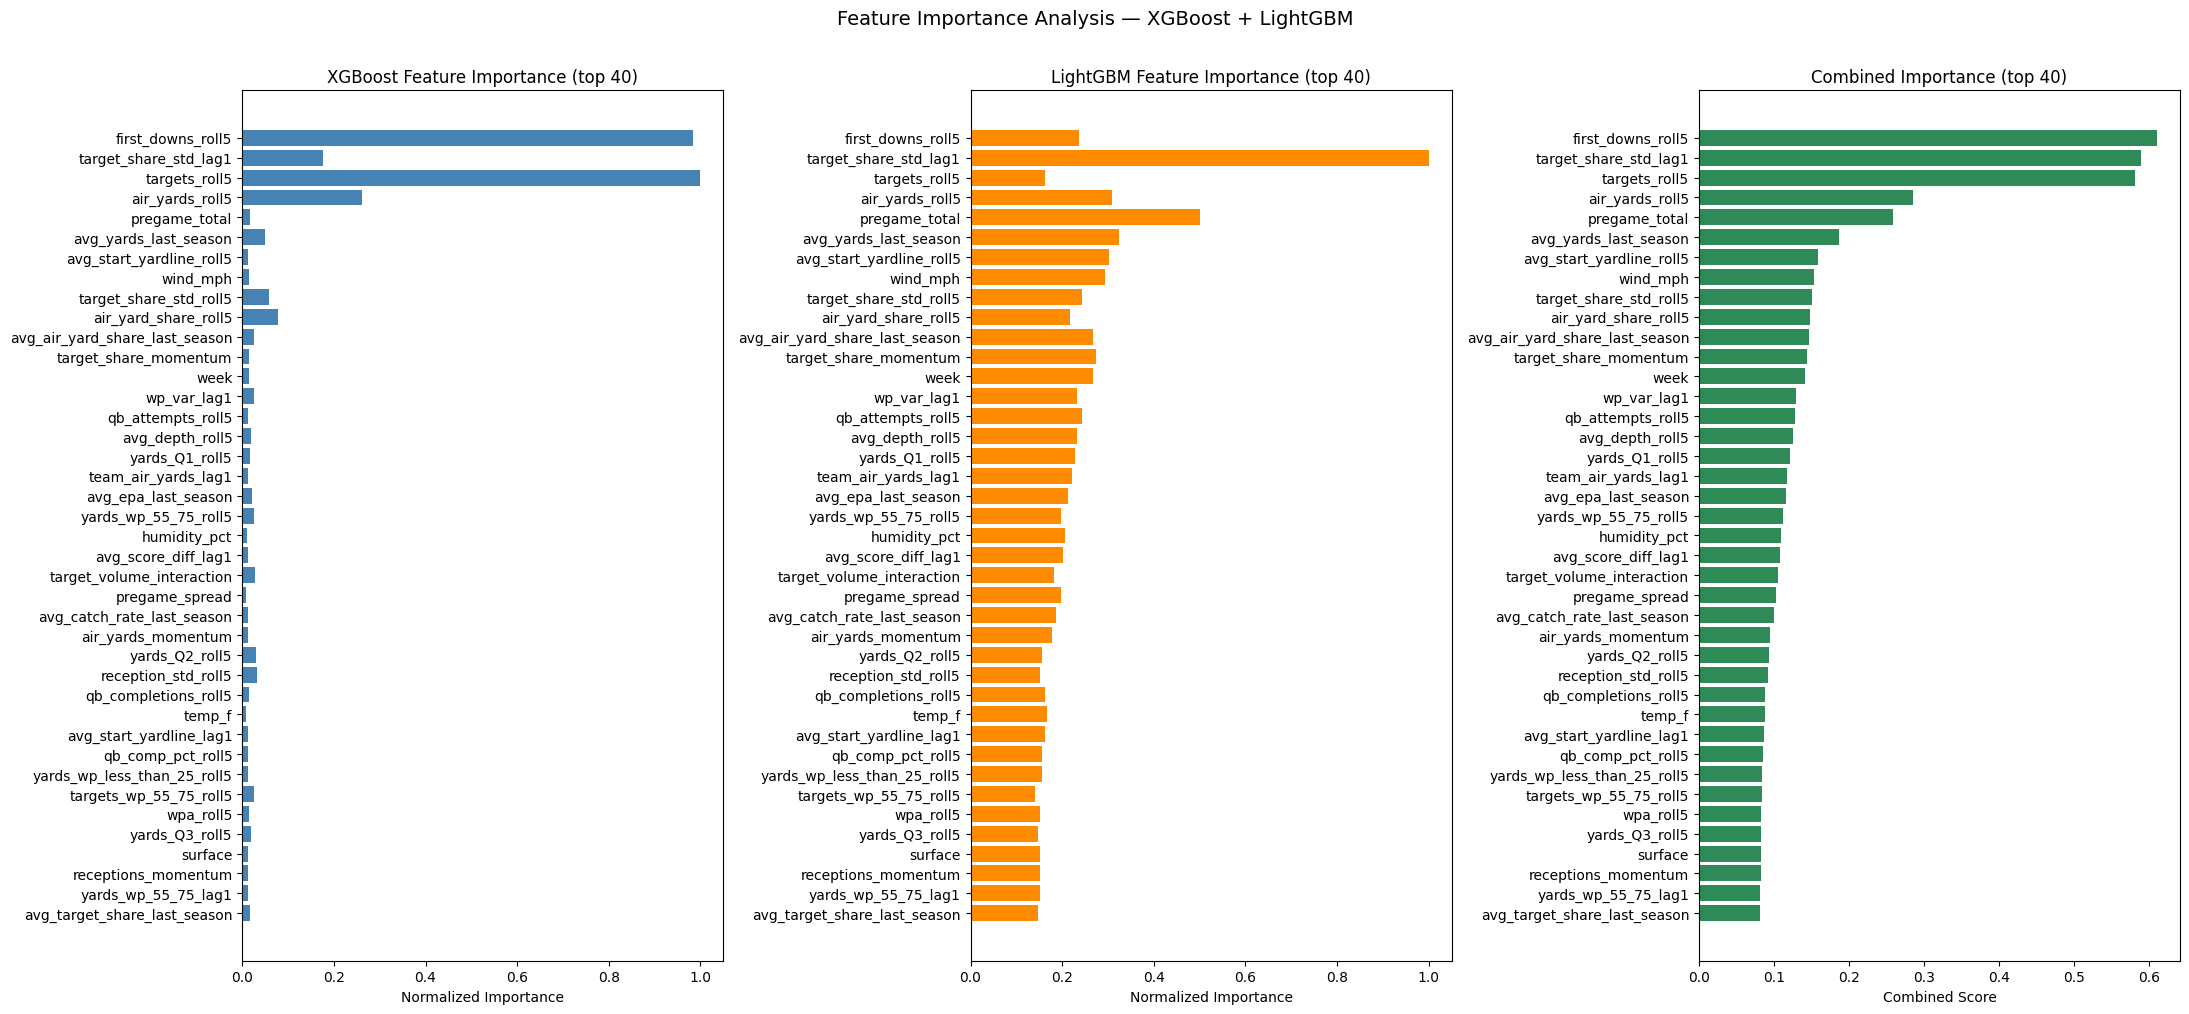

In [11]:
# Visualize feature importance — Top 40
top40 = fi_df.head(40)

fig, axes = plt.subplots(1, 3, figsize=(22, 10))

# XGBoost importance
axes[0].barh(top40['feature'][::-1], top40['xgb_normalized'][::-1], color='steelblue')
axes[0].set_title('XGBoost Feature Importance (top 40)')
axes[0].set_xlabel('Normalized Importance')

# LightGBM importance
axes[1].barh(top40['feature'][::-1], top40['lgb_normalized'][::-1], color='darkorange')
axes[1].set_title('LightGBM Feature Importance (top 40)')
axes[1].set_xlabel('Normalized Importance')

# Combined
axes[2].barh(top40['feature'][::-1], top40['combined_score'][::-1], color='seagreen')
axes[2].set_title('Combined Importance (top 40)')
axes[2].set_xlabel('Combined Score')

plt.suptitle('Feature Importance Analysis — XGBoost + LightGBM', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../results/feature_importance_top40.png', dpi=150, bbox_inches='tight')
plt.show()

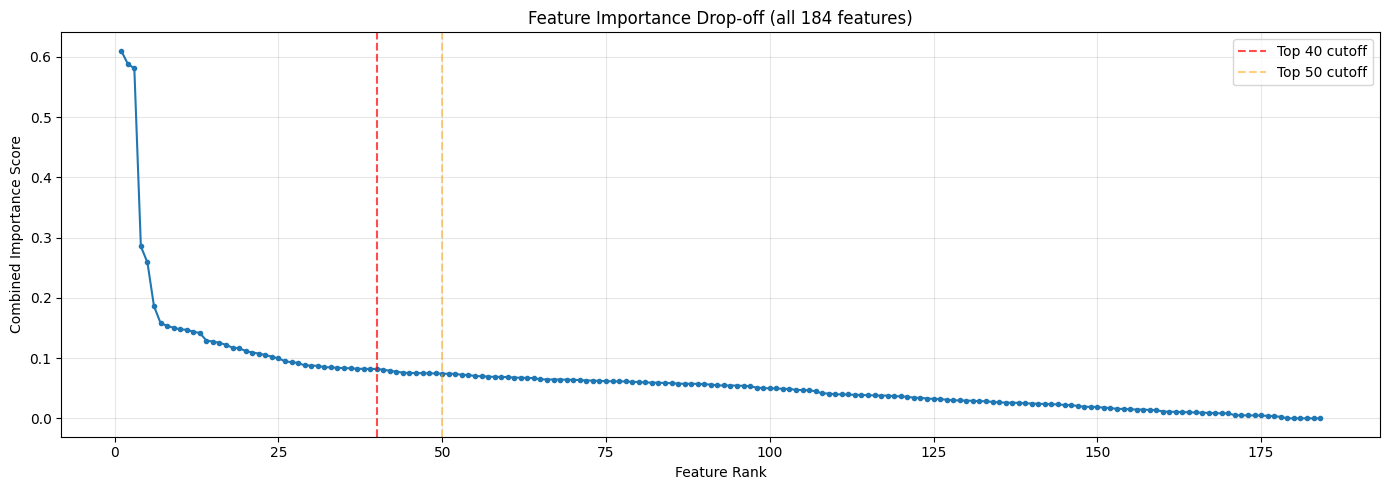


Cumulative importance captured:
  Top  20 features: 36.7%
  Top  30 features: 44.9%
  Top  40 features: 51.8%
  Top  50 features: 58.2%
  Top  60 features: 64.1%
  Top  80 features: 74.7%
  Top 100 features: 84.0%


In [12]:
# Show the importance drop-off — where does the "elbow" occur?
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(range(1, len(fi_df) + 1), fi_df['combined_score'].values, 'o-', markersize=3)
ax.axvline(x=40, color='r', linestyle='--', alpha=0.7, label='Top 40 cutoff')
ax.axvline(x=50, color='orange', linestyle='--', alpha=0.5, label='Top 50 cutoff')
ax.set_xlabel('Feature Rank')
ax.set_ylabel('Combined Importance Score')
ax.set_title('Feature Importance Drop-off (all 184 features)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Cumulative importance
cumulative = np.cumsum(fi_df['combined_score'].values) / fi_df['combined_score'].sum()
print(f'\nCumulative importance captured:')
for k in [20, 30, 40, 50, 60, 80, 100]:
    if k <= len(cumulative):
        print(f'  Top {k:>3d} features: {cumulative[k-1]:.1%}')

In [13]:
# Select top 40 features
N_SELECTED = 40
selected_features = fi_df.head(N_SELECTED)['feature'].tolist()

print(f'Selected {N_SELECTED} features:')
for i, f in enumerate(selected_features, 1):
    score = fi_df.loc[fi_df['feature'] == f, 'combined_score'].values[0]
    print(f'  {i:>2d}. {f:<45s} (score: {score:.4f})')

# Bottom features that are being dropped
dropped_features = fi_df.tail(20)['feature'].tolist()
print(f'\nBottom 20 features (being dropped):')
for f in dropped_features:
    score = fi_df.loc[fi_df['feature'] == f, 'combined_score'].values[0]
    print(f'  - {f:<45s} (score: {score:.6f})')

Selected 40 features:
   1. first_downs_roll5                             (score: 0.6102)
   2. target_share_std_lag1                         (score: 0.5884)
   3. targets_roll5                                 (score: 0.5808)
   4. air_yards_roll5                               (score: 0.2852)
   5. pregame_total                                 (score: 0.2588)
   6. avg_yards_last_season                         (score: 0.1863)
   7. avg_start_yardline_roll5                      (score: 0.1583)
   8. wind_mph                                      (score: 0.1535)
   9. target_share_std_roll5                        (score: 0.1504)
  10. air_yard_share_roll5                          (score: 0.1477)
  11. avg_air_yard_share_last_season                (score: 0.1471)
  12. target_share_momentum                         (score: 0.1437)
  13. week                                          (score: 0.1417)
  14. wp_var_lag1                                   (score: 0.1291)
  15. qb_attempts_roll5   

---
## 3. Prepare Reduced Feature Sets

Build train/val/test matrices for the top 40 features.

In [14]:
# Get column indices for selected features
selected_indices = [all_feature_columns.index(f) for f in selected_features]

X_train_sel = train_df[selected_features].values
X_val_sel = val_df[selected_features].values
X_test_sel = test_df[selected_features].values

scaler_sel = StandardScaler()
X_train_sel_sc = scaler_sel.fit_transform(X_train_sel)
X_val_sel_sc = scaler_sel.transform(X_val_sel)
X_test_sel_sc = scaler_sel.transform(X_test_sel)

print(f'All features shape:      {X_train_all_sc.shape}')
print(f'Selected features shape: {X_train_sel_sc.shape}')

All features shape:      (29276, 184)
Selected features shape: (29276, 40)


---
## 4. Learning Curves — All Features (184)

Train XGBoost and LightGBM with `eval_set` to track train/val loss per boosting round.
Uses the same hyperparameters as `WR_Career_RNN_Optuna.ipynb`.

In [15]:
def evaluate_model(y_true_orig, y_pred_sqrt):
    """Convert sqrt predictions back to original scale and compute metrics."""
    y_pred_orig = np.clip(y_pred_sqrt, 0, None) ** 2
    mae = mean_absolute_error(y_true_orig, y_pred_orig)
    rmse = np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))
    r2 = r2_score(y_true_orig, y_pred_orig)
    return mae, rmse, r2, y_pred_orig

In [16]:
# === XGBoost — ALL features (184) with learning curve ===
xgb_all = XGBRegressor(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
    random_state=SEED, n_jobs=-1, verbosity=0,
    eval_metric='rmse'
)
xgb_all.fit(
    X_train_all_sc, y_train_sqrt,
    sample_weight=sample_weights_train,
    eval_set=[(X_train_all_sc, y_train_sqrt), (X_val_all_sc, y_val_sqrt)],
    verbose=False
)
xgb_all_train_rmse = xgb_all.evals_result()['validation_0']['rmse']
xgb_all_val_rmse = xgb_all.evals_result()['validation_1']['rmse']

mae, rmse, r2, _ = evaluate_model(y_test_orig, xgb_all.predict(X_test_all_sc))
print(f'XGBoost (ALL 184 features)  | MAE={mae:.2f}  RMSE={rmse:.2f}  R2={r2:.4f}')
print(f'  Final train RMSE (sqrt): {xgb_all_train_rmse[-1]:.4f}')
print(f'  Final val RMSE (sqrt):   {xgb_all_val_rmse[-1]:.4f}')
print(f'  Gap (val - train):       {xgb_all_val_rmse[-1] - xgb_all_train_rmse[-1]:.4f}')

XGBoost (ALL 184 features)  | MAE=18.15  RMSE=25.15  R2=0.3335
  Final train RMSE (sqrt): 2.3760
  Final val RMSE (sqrt):   2.4913
  Gap (val - train):       0.1153


In [17]:
# === LightGBM — ALL features (184) with learning curve ===
lgb_all = LGBMRegressor(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, num_leaves=31, reg_alpha=0.1, reg_lambda=1.0,
    random_state=SEED, n_jobs=-1, verbosity=-1,
    metric='rmse'
)
lgb_all.fit(
    X_train_all_sc, y_train_sqrt,
    sample_weight=sample_weights_train,
    eval_set=[(X_train_all_sc, y_train_sqrt), (X_val_all_sc, y_val_sqrt)],
    eval_metric='rmse'
)
lgb_all_train_rmse = lgb_all.evals_result_['training']['rmse']
lgb_all_val_rmse = lgb_all.evals_result_['valid_1']['rmse']

mae, rmse, r2, _ = evaluate_model(y_test_orig, lgb_all.predict(X_test_all_sc))
print(f'LightGBM (ALL 184 features) | MAE={mae:.2f}  RMSE={rmse:.2f}  R2={r2:.4f}')
print(f'  Final train RMSE (sqrt): {lgb_all_train_rmse[-1]:.4f}')
print(f'  Final val RMSE (sqrt):   {lgb_all_val_rmse[-1]:.4f}')
print(f'  Gap (val - train):       {lgb_all_val_rmse[-1] - lgb_all_train_rmse[-1]:.4f}')

LightGBM (ALL 184 features) | MAE=18.15  RMSE=25.13  R2=0.3346
  Final train RMSE (sqrt): 2.2592
  Final val RMSE (sqrt):   2.4957
  Gap (val - train):       0.2365


---
## 5. Learning Curves — Selected Features (Top 40)

Same models, same hyperparameters, but trained on only the top 40 features.

In [18]:
# === XGBoost — SELECTED features (top 40) with learning curve ===
xgb_sel = XGBRegressor(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
    random_state=SEED, n_jobs=-1, verbosity=0,
    eval_metric='rmse'
)
xgb_sel.fit(
    X_train_sel_sc, y_train_sqrt,
    sample_weight=sample_weights_train,
    eval_set=[(X_train_sel_sc, y_train_sqrt), (X_val_sel_sc, y_val_sqrt)],
    verbose=False
)
xgb_sel_train_rmse = xgb_sel.evals_result()['validation_0']['rmse']
xgb_sel_val_rmse = xgb_sel.evals_result()['validation_1']['rmse']

mae, rmse, r2, _ = evaluate_model(y_test_orig, xgb_sel.predict(X_test_sel_sc))
print(f'XGBoost (TOP 40 features)   | MAE={mae:.2f}  RMSE={rmse:.2f}  R2={r2:.4f}')
print(f'  Final train RMSE (sqrt): {xgb_sel_train_rmse[-1]:.4f}')
print(f'  Final val RMSE (sqrt):   {xgb_sel_val_rmse[-1]:.4f}')
print(f'  Gap (val - train):       {xgb_sel_val_rmse[-1] - xgb_sel_train_rmse[-1]:.4f}')

XGBoost (TOP 40 features)   | MAE=18.24  RMSE=25.19  R2=0.3310
  Final train RMSE (sqrt): 2.4027
  Final val RMSE (sqrt):   2.5045
  Gap (val - train):       0.1019


In [19]:
# === LightGBM — SELECTED features (top 40) with learning curve ===
lgb_sel = LGBMRegressor(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, num_leaves=31, reg_alpha=0.1, reg_lambda=1.0,
    random_state=SEED, n_jobs=-1, verbosity=-1,
    metric='rmse'
)
lgb_sel.fit(
    X_train_sel_sc, y_train_sqrt,
    sample_weight=sample_weights_train,
    eval_set=[(X_train_sel_sc, y_train_sqrt), (X_val_sel_sc, y_val_sqrt)],
    eval_metric='rmse'
)
lgb_sel_train_rmse = lgb_sel.evals_result_['training']['rmse']
lgb_sel_val_rmse = lgb_sel.evals_result_['valid_1']['rmse']

mae, rmse, r2, _ = evaluate_model(y_test_orig, lgb_sel.predict(X_test_sel_sc))
print(f'LightGBM (TOP 40 features)  | MAE={mae:.2f}  RMSE={rmse:.2f}  R2={r2:.4f}')
print(f'  Final train RMSE (sqrt): {lgb_sel_train_rmse[-1]:.4f}')
print(f'  Final val RMSE (sqrt):   {lgb_sel_val_rmse[-1]:.4f}')
print(f'  Gap (val - train):       {lgb_sel_val_rmse[-1] - lgb_sel_train_rmse[-1]:.4f}')

LightGBM (TOP 40 features)  | MAE=18.24  RMSE=25.25  R2=0.3278
  Final train RMSE (sqrt): 2.2822
  Final val RMSE (sqrt):   2.5073
  Gap (val - train):       0.2251


---
## 6. Learning Curve Comparison Plots

Side-by-side comparison: All 184 features vs Top 40 features.
Key metric: the **train-val gap** — smaller gap = less overfit.

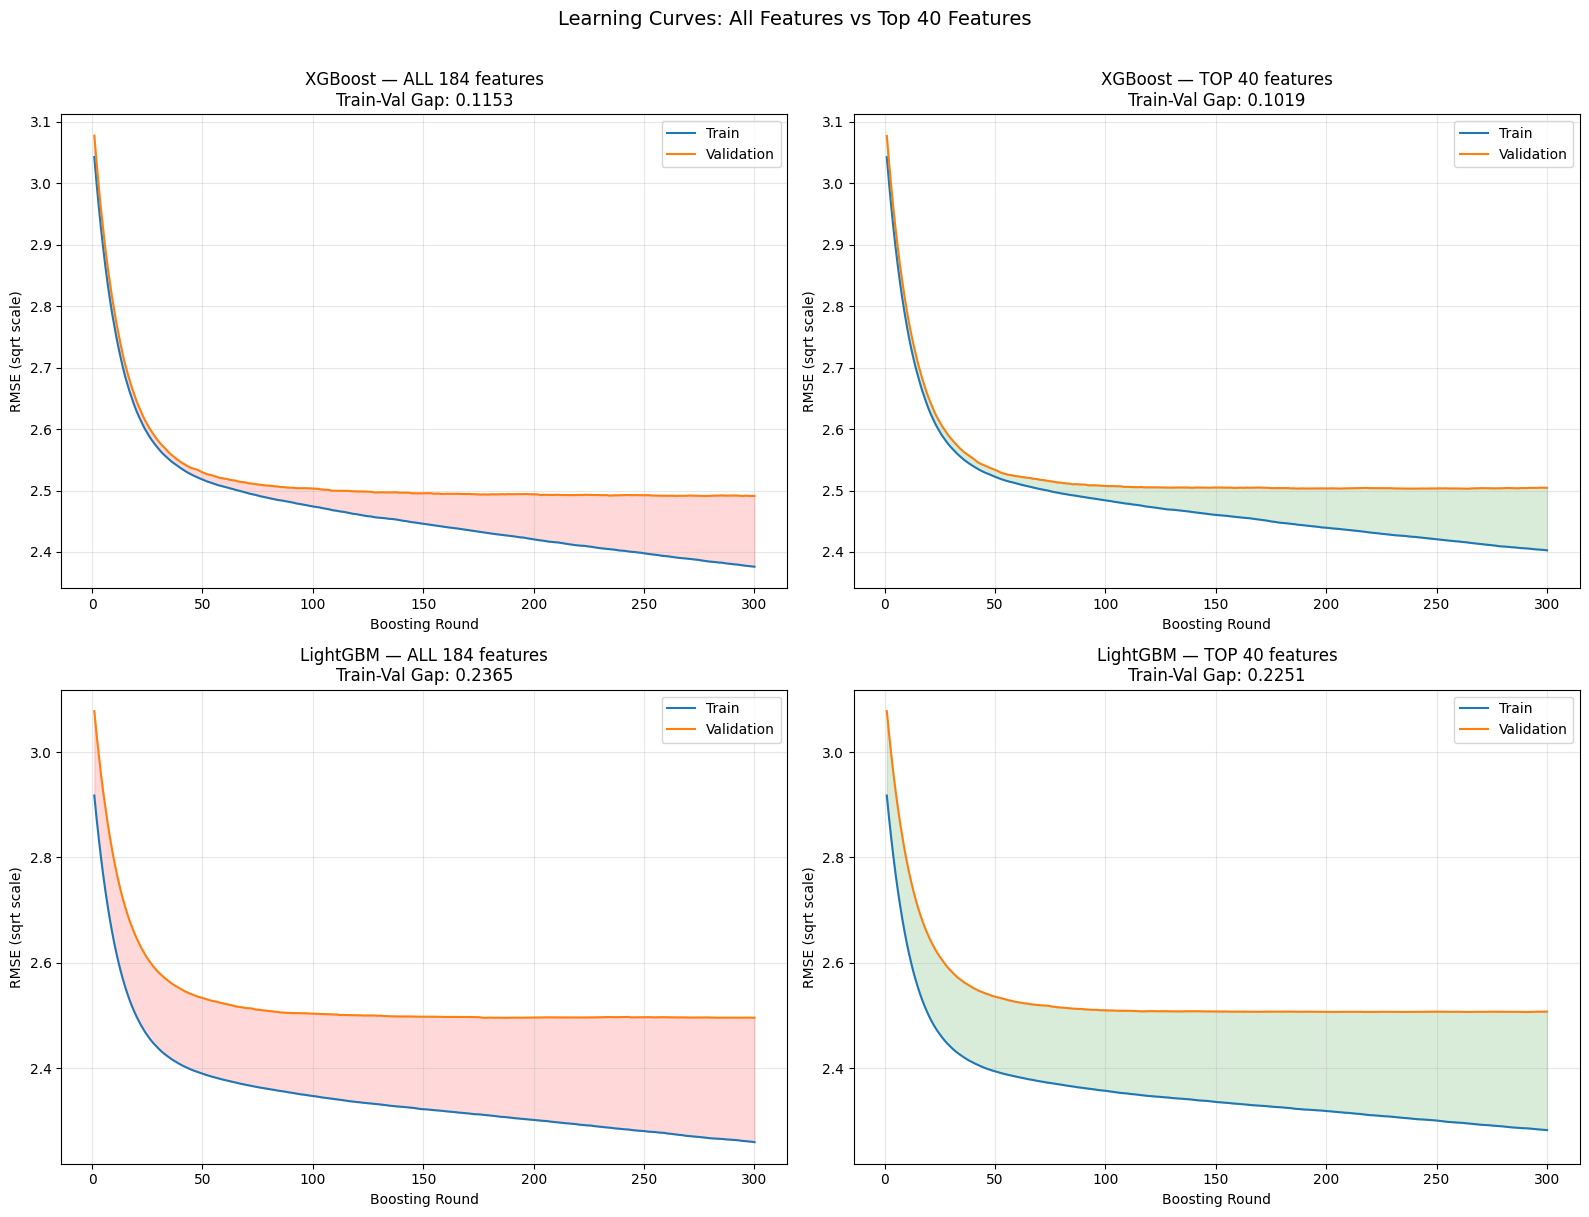

In [20]:
rounds = range(1, 301)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- XGBoost: All features ---
ax = axes[0, 0]
ax.plot(rounds, xgb_all_train_rmse, label='Train', linewidth=1.5)
ax.plot(rounds, xgb_all_val_rmse, label='Validation', linewidth=1.5)
ax.fill_between(rounds, xgb_all_train_rmse, xgb_all_val_rmse, alpha=0.15, color='red')
gap_all_xgb = xgb_all_val_rmse[-1] - xgb_all_train_rmse[-1]
ax.set_title(f'XGBoost — ALL 184 features\nTrain-Val Gap: {gap_all_xgb:.4f}', fontsize=12)
ax.set_xlabel('Boosting Round')
ax.set_ylabel('RMSE (sqrt scale)')
ax.legend()
ax.grid(True, alpha=0.3)

# --- XGBoost: Selected features ---
ax = axes[0, 1]
ax.plot(rounds, xgb_sel_train_rmse, label='Train', linewidth=1.5)
ax.plot(rounds, xgb_sel_val_rmse, label='Validation', linewidth=1.5)
ax.fill_between(rounds, xgb_sel_train_rmse, xgb_sel_val_rmse, alpha=0.15, color='green')
gap_sel_xgb = xgb_sel_val_rmse[-1] - xgb_sel_train_rmse[-1]
ax.set_title(f'XGBoost — TOP 40 features\nTrain-Val Gap: {gap_sel_xgb:.4f}', fontsize=12)
ax.set_xlabel('Boosting Round')
ax.set_ylabel('RMSE (sqrt scale)')
ax.legend()
ax.grid(True, alpha=0.3)

# --- LightGBM: All features ---
ax = axes[1, 0]
ax.plot(rounds, lgb_all_train_rmse, label='Train', linewidth=1.5)
ax.plot(rounds, lgb_all_val_rmse, label='Validation', linewidth=1.5)
ax.fill_between(rounds, lgb_all_train_rmse, lgb_all_val_rmse, alpha=0.15, color='red')
gap_all_lgb = lgb_all_val_rmse[-1] - lgb_all_train_rmse[-1]
ax.set_title(f'LightGBM — ALL 184 features\nTrain-Val Gap: {gap_all_lgb:.4f}', fontsize=12)
ax.set_xlabel('Boosting Round')
ax.set_ylabel('RMSE (sqrt scale)')
ax.legend()
ax.grid(True, alpha=0.3)

# --- LightGBM: Selected features ---
ax = axes[1, 1]
ax.plot(rounds, lgb_sel_train_rmse, label='Train', linewidth=1.5)
ax.plot(rounds, lgb_sel_val_rmse, label='Validation', linewidth=1.5)
ax.fill_between(rounds, lgb_sel_train_rmse, lgb_sel_val_rmse, alpha=0.15, color='green')
gap_sel_lgb = lgb_sel_val_rmse[-1] - lgb_sel_train_rmse[-1]
ax.set_title(f'LightGBM — TOP 40 features\nTrain-Val Gap: {gap_sel_lgb:.4f}', fontsize=12)
ax.set_xlabel('Boosting Round')
ax.set_ylabel('RMSE (sqrt scale)')
ax.legend()
ax.grid(True, alpha=0.3)

# Equalize y-axis across each row
for row in range(2):
    ymin = min(axes[row, 0].get_ylim()[0], axes[row, 1].get_ylim()[0])
    ymax = max(axes[row, 0].get_ylim()[1], axes[row, 1].get_ylim()[1])
    axes[row, 0].set_ylim(ymin, ymax)
    axes[row, 1].set_ylim(ymin, ymax)

plt.suptitle('Learning Curves: All Features vs Top 40 Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../results/feature_selection_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

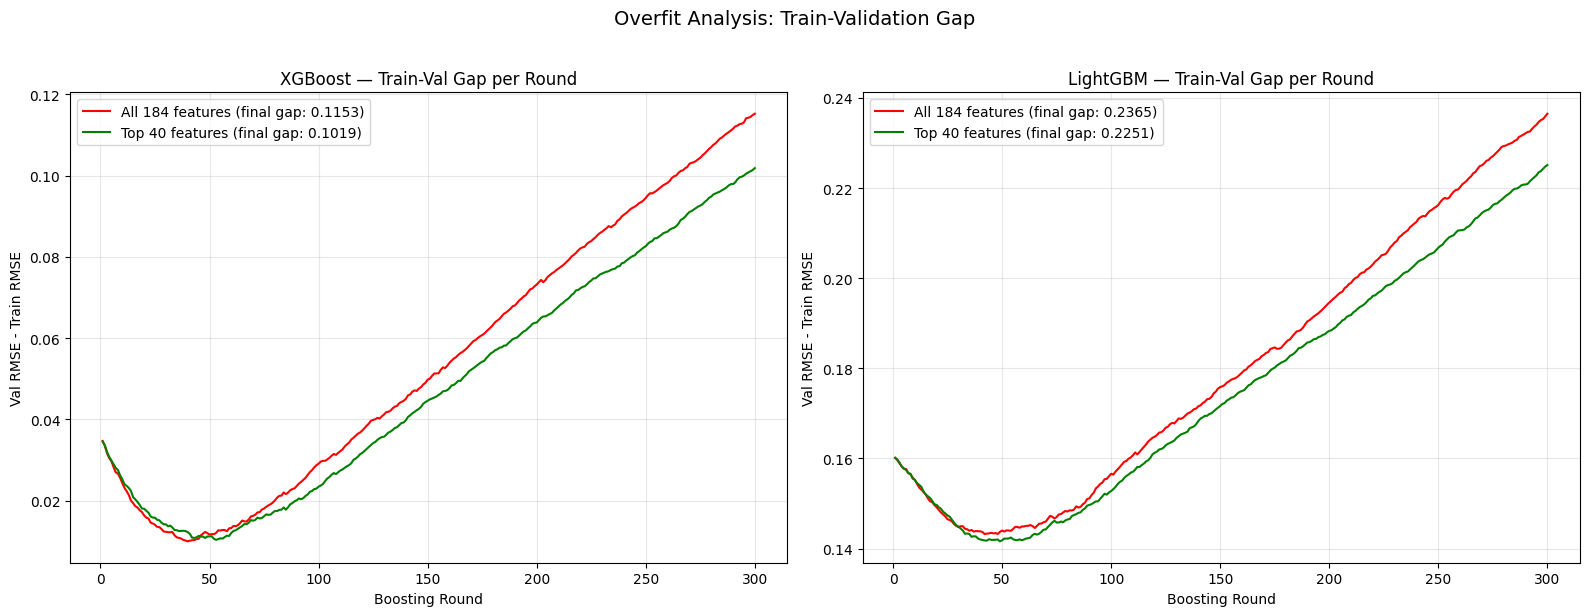

In [21]:
# --- Overlay plots: direct train-val gap comparison ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# XGBoost overlay
ax = axes[0]
xgb_gap_all = [v - t for t, v in zip(xgb_all_train_rmse, xgb_all_val_rmse)]
xgb_gap_sel = [v - t for t, v in zip(xgb_sel_train_rmse, xgb_sel_val_rmse)]
ax.plot(rounds, xgb_gap_all, label=f'All 184 features (final gap: {xgb_gap_all[-1]:.4f})', linewidth=1.5, color='red')
ax.plot(rounds, xgb_gap_sel, label=f'Top 40 features (final gap: {xgb_gap_sel[-1]:.4f})', linewidth=1.5, color='green')
ax.set_title('XGBoost — Train-Val Gap per Round', fontsize=12)
ax.set_xlabel('Boosting Round')
ax.set_ylabel('Val RMSE - Train RMSE')
ax.legend()
ax.grid(True, alpha=0.3)

# LightGBM overlay
ax = axes[1]
lgb_gap_all = [v - t for t, v in zip(lgb_all_train_rmse, lgb_all_val_rmse)]
lgb_gap_sel = [v - t for t, v in zip(lgb_sel_train_rmse, lgb_sel_val_rmse)]
ax.plot(rounds, lgb_gap_all, label=f'All 184 features (final gap: {lgb_gap_all[-1]:.4f})', linewidth=1.5, color='red')
ax.plot(rounds, lgb_gap_sel, label=f'Top 40 features (final gap: {lgb_gap_sel[-1]:.4f})', linewidth=1.5, color='green')
ax.set_title('LightGBM — Train-Val Gap per Round', fontsize=12)
ax.set_xlabel('Boosting Round')
ax.set_ylabel('Val RMSE - Train RMSE')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('Overfit Analysis: Train-Validation Gap', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../results/feature_selection_overfit_gap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Final Comparison Table

In [22]:
# Collect all results
results = {}

# All features
mae, rmse, r2, _ = evaluate_model(y_test_orig, xgb_all.predict(X_test_all_sc))
results['XGBoost (184 features)'] = {'MAE': mae, 'RMSE': rmse, 'R2': r2,
    'Train RMSE (sqrt)': xgb_all_train_rmse[-1],
    'Val RMSE (sqrt)': xgb_all_val_rmse[-1],
    'Overfit Gap': xgb_all_val_rmse[-1] - xgb_all_train_rmse[-1]}

mae, rmse, r2, _ = evaluate_model(y_test_orig, lgb_all.predict(X_test_all_sc))
results['LightGBM (184 features)'] = {'MAE': mae, 'RMSE': rmse, 'R2': r2,
    'Train RMSE (sqrt)': lgb_all_train_rmse[-1],
    'Val RMSE (sqrt)': lgb_all_val_rmse[-1],
    'Overfit Gap': lgb_all_val_rmse[-1] - lgb_all_train_rmse[-1]}

# Selected features
mae, rmse, r2, _ = evaluate_model(y_test_orig, xgb_sel.predict(X_test_sel_sc))
results['XGBoost (40 features)'] = {'MAE': mae, 'RMSE': rmse, 'R2': r2,
    'Train RMSE (sqrt)': xgb_sel_train_rmse[-1],
    'Val RMSE (sqrt)': xgb_sel_val_rmse[-1],
    'Overfit Gap': xgb_sel_val_rmse[-1] - xgb_sel_train_rmse[-1]}

mae, rmse, r2, _ = evaluate_model(y_test_orig, lgb_sel.predict(X_test_sel_sc))
results['LightGBM (40 features)'] = {'MAE': mae, 'RMSE': rmse, 'R2': r2,
    'Train RMSE (sqrt)': lgb_sel_train_rmse[-1],
    'Val RMSE (sqrt)': lgb_sel_val_rmse[-1],
    'Overfit Gap': lgb_sel_val_rmse[-1] - lgb_sel_train_rmse[-1]}

results_df = pd.DataFrame(results).T
results_df.index.name = 'Model'

print('\n' + '=' * 90)
print('COMPARISON: All Features vs Top 40 Features')
print('=' * 90)
print(results_df.round(4).to_string())
print('=' * 90)


COMPARISON: All Features vs Top 40 Features
                             MAE     RMSE      R2  Train RMSE (sqrt)  Val RMSE (sqrt)  Overfit Gap
Model                                                                                             
XGBoost (184 features)   18.1505  25.1460  0.3335             2.3760           2.4913       0.1153
LightGBM (184 features)  18.1496  25.1258  0.3346             2.2592           2.4957       0.2365
XGBoost (40 features)    18.2370  25.1937  0.3310             2.4027           2.5045       0.1019
LightGBM (40 features)   18.2448  25.2532  0.3278             2.2822           2.5073       0.2251


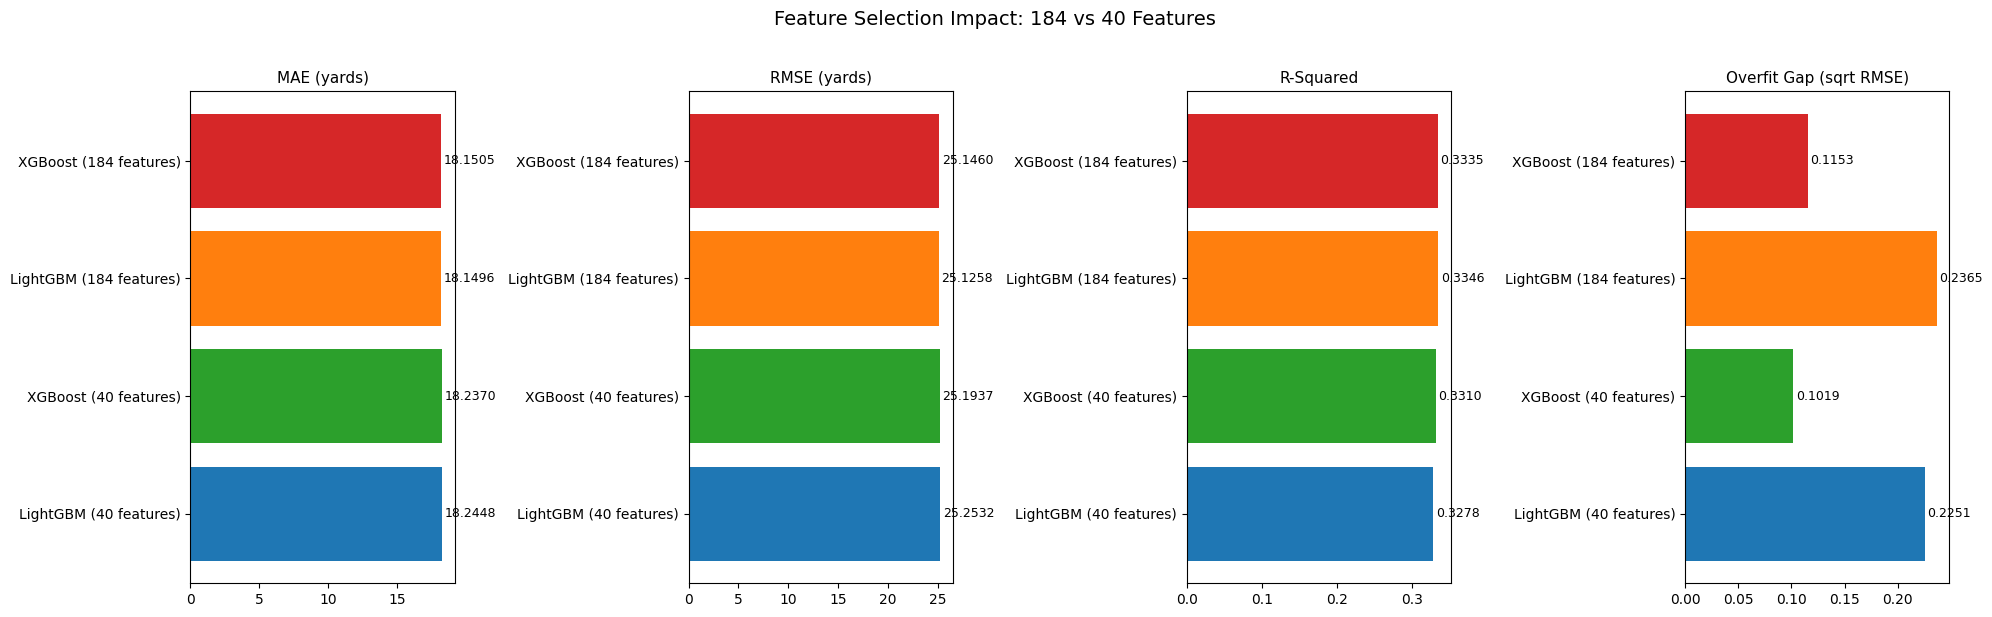

In [23]:
# --- Bar chart comparison ---
fig, axes = plt.subplots(1, 4, figsize=(20, 6))

models = results_df.index.tolist()
colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4']

for idx, (metric, title) in enumerate([
    ('MAE', 'MAE (yards)'),
    ('RMSE', 'RMSE (yards)'),
    ('R2', 'R-Squared'),
    ('Overfit Gap', 'Overfit Gap (sqrt RMSE)'),
]):
    ax = axes[idx]
    vals = results_df[metric].values
    ax.barh(models, vals, color=colors)
    ax.set_title(title, fontsize=11)
    ax.invert_yaxis()
    for i, v in enumerate(vals):
        ax.text(v + 0.01 * max(vals), i, f'{v:.4f}', va='center', fontsize=9)

plt.suptitle('Feature Selection Impact: 184 vs 40 Features', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../results/feature_selection_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
# Save selected features list for use in other notebooks
output = {
    'n_selected': N_SELECTED,
    'selected_features': selected_features,
    'feature_importance': fi_df[['feature', 'combined_score']].to_dict('records'),
    'results': {k: {kk: round(vv, 4) for kk, vv in v.items()} for k, v in results.items()},
}

with open('../results/selected_features_top40.json', 'w') as f:
    json.dump(output, f, indent=2)

# Also save as simple text list
with open('../results/selected_features_top40.txt', 'w') as f:
    for feat in selected_features:
        f.write(feat + '\n')

print(f'Saved selected features to:')
print(f'  results/selected_features_top40.json')
print(f'  results/selected_features_top40.txt')
print(f'\nThese {N_SELECTED} features will be used in the next notebook for RNN/TCN training.')

Saved selected features to:
  results/selected_features_top40.json
  results/selected_features_top40.txt

These 40 features will be used in the next notebook for RNN/TCN training.
